In [10]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# ----- DURATION HISTOGRAM: Shows the duration of each audio sample
# ---------- Need the audio files for this

current_dir = os.getcwd()  # Folder where this notebook runs (EDA/)
project_root = os.path.abspath(os.path.join(current_dir, ".."))  # Go one level up to project root

# Paths relative to project root
audio_root = os.path.join(project_root, "training_data", "training")  # training audio folder
plots_dir = os.path.join(current_dir, "Plots")  # Save plots locally inside EDA/Plots

# Ensure the output folder exists
os.makedirs(plots_dir, exist_ok=True)

# === Collect Durations ===
durations = []

for root, dirs, files in os.walk(audio_root):
    for file in files:
        if file.lower().endswith(".wav"):
            file_path = os.path.join(root, file)
            try:
                y, sr = librosa.load(file_path, sr=None)
                duration = len(y) / sr
                durations.append(duration)
            except Exception as e:
                print(f"Error loading {file}: {e}")

print(f"Processed {len(durations)} audio files.")

# Ensure data exists
if not durations:
    raise ValueError("No audio durations found! Check your folder structure or file formats.")

Processed 2176 audio files.


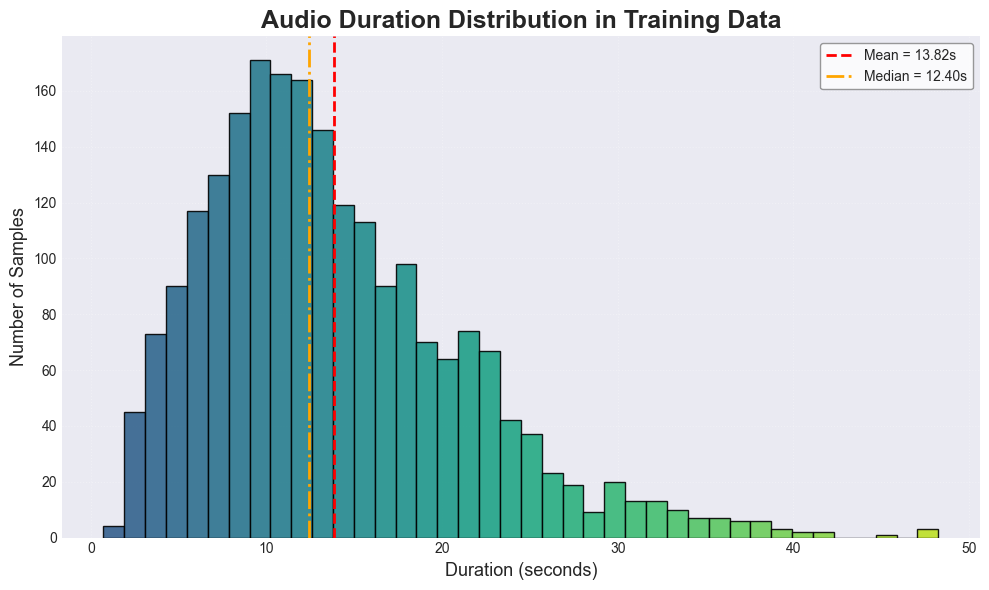

Duration histogram saved successfully at:
d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\duration_histogram.pdf


In [13]:
# === Plot Styling ===
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
n_bins = 40
colors = plt.cm.viridis(np.linspace(0.3, 0.9, n_bins))
n, bins, patches = ax.hist(durations, bins=n_bins, edgecolor='black', alpha=0.9)

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

# Labels and decorations
mean_dur = np.mean(durations)
median_dur = np.median(durations)

ax.axvline(mean_dur, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_dur:.2f}s")
ax.axvline(median_dur, color='orange', linestyle='-.', linewidth=2, label=f"Median = {median_dur:.2f}s")

ax.set_title("Audio Duration Distribution in Training Data", fontsize=18, fontweight='bold')
ax.set_xlabel("Duration (seconds)", fontsize=13)
ax.set_ylabel("Number of Samples", fontsize=13)
ax.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=10)
ax.grid(alpha=0.3, linestyle=':')
fig.tight_layout()

# === Save before showing ===
output_path = os.path.join(plots_dir, "duration_histogram.pdf")
fig.savefig(output_path, format='pdf', bbox_inches='tight')

# Display
plt.show()

print(f"Duration histogram saved successfully at:\n{output_path}")
